In [35]:
# Market Risk Modelling and Stress Testing of an AMC Portfolio
# An Empirical Study

# Objective:
# To measure market risk exposure of an AMC portfolio using quantitative techniques 
# such as volatility analysis, Value at Risk (VaR), Monte Carlo simulation, 
# Expected Shortfall, GARCH volatility modelling, and Copula tail dependence.

In [36]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy.stats import norm
from scipy.stats import t
from arch import arch_model

plt.style.use('seaborn-v0_8')

In [37]:
holdings = {
    "HDFCBANK.NS": 9.89,
    "ICICIBANK.NS": 9.62,
    "AXISBANK.NS": 7.81,
    "KOTAKBANK.NS": 5.85,
    "SBIN.NS": 5.60,
    "HCLTECH.NS": 4.80,
    "CIPLA.NS": 3.84,
    "MARUTI.NS": 3.79,
    "BHARTIARTL.NS": 3.60,
    "SBILIFE.NS": 3.57,
    "POWERGRID.NS": 2.63,
    "EICHERMOT.NS": 2.52,
    "HAVELLS.NS": 2.48,
    "TATASTEEL.NS": 2.35,
    "BAJAJ-AUTO.NS": 2.19,
    "KARURVYSYA.NS": 2.13,
    "NYKAA.NS": 1.80,
    "PPLPHARMA.NS": 1.77,
    "ESCORTS.NS": 1.73,
    "CHALET.NS": 1.69,
    "SUNDRMFAST.NS": 1.56,
    "INDIGO.NS": 1.44,
    "BOSCHLTD.NS": 1.39,
    "METROPOLIS.NS": 1.21,
    "CIEINDIA.NS": 1.13,
    "CROMPTON.NS": 0.79,
    "SAPPHIRE.NS": 0.68,
    "RBA.NS": 0.54
}

In [38]:
tickers = list(holdings.keys())

prices = yf.download(tickers, start='2023-01-01', end='2025-12-31')['Close']

[*********************100%***********************]  28 of 28 completed


In [39]:
weights_df = pd.DataFrame.from_dict(holdings, orient='index', columns=['Weight_%'])

weights_df['Weight'] = weights_df['Weight_%'] / 100
weights_df['Weight'] = weights_df['Weight'] / weights_df['Weight'].sum()

weights = weights_df['Weight'].values

In [40]:
weights_df['Weight'].sum()


np.float64(1.0)

In [41]:
returns = np.log(prices / prices.shift(1)).dropna()

portfolio_returns = returns.dot(weights)
print(portfolio_returns)

Date
2023-01-03    0.003805
2023-01-04   -0.008659
2023-01-05    0.001139
2023-01-06   -0.003686
2023-01-09    0.010315
                ...   
2025-12-23    0.002261
2025-12-24   -0.002617
2025-12-26   -0.003788
2025-12-29   -0.003483
2025-12-30    0.002098
Length: 738, dtype: float64


In [42]:
portfolio_vol_daily = portfolio_returns.std()
portfolio_vol_annual = portfolio_vol_daily * np.sqrt(252)

print("Daily Volatility:", portfolio_vol_daily)
print("Annualized Volatility:", portfolio_vol_annual)

Daily Volatility: 0.007760799744790075
Annualized Volatility: 0.12319887659812849


In [43]:
risk_free_rate = 0.06 / 252  # 6% annual RF assumption

sharpe_ratio = (portfolio_returns.mean() - risk_free_rate) / portfolio_returns.std()
sharpe_ratio_annual = sharpe_ratio * np.sqrt(252)

print("Annualized Sharpe Ratio:", sharpe_ratio_annual)

Annualized Sharpe Ratio: 1.031946705357277


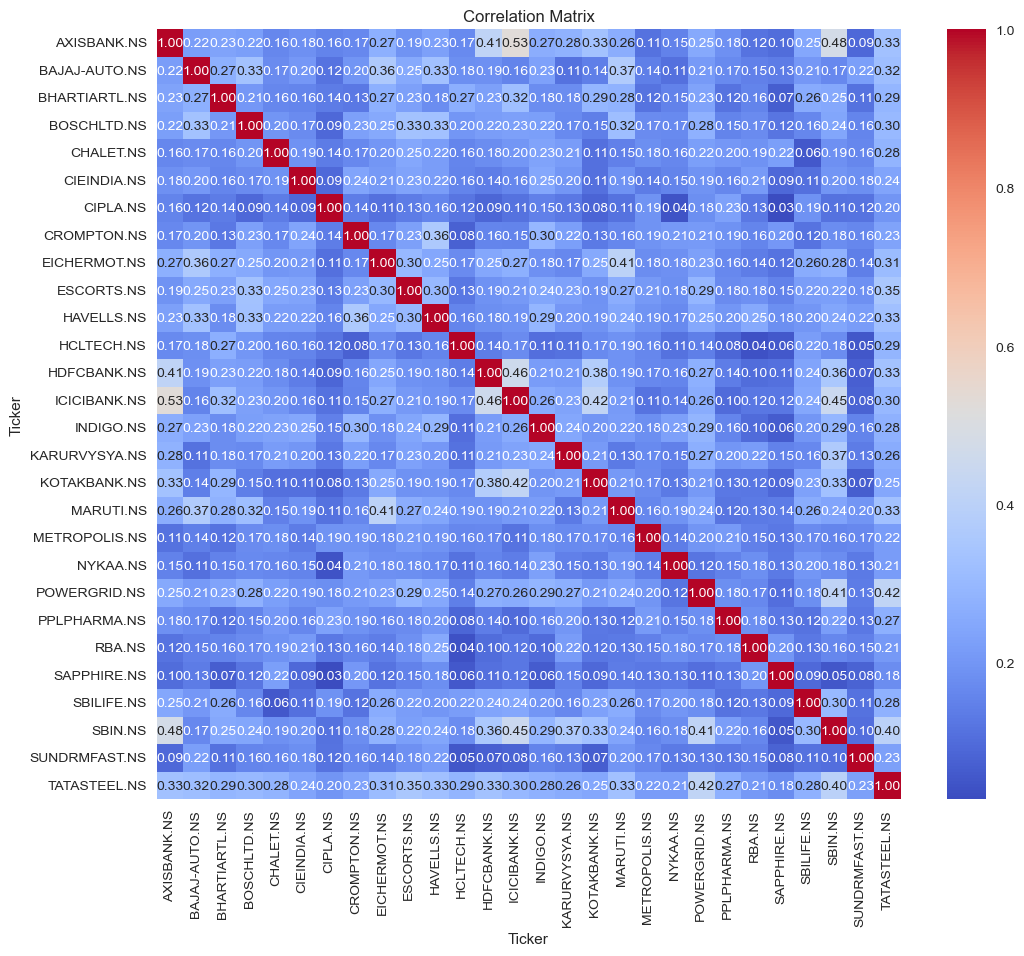

In [44]:
plt.figure(figsize=(12,10))
sns.heatmap(returns.corr(), cmap='coolwarm', annot=True, fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [45]:
market = yf.download("^NSEI", start="2023-01-01", end="2025-12-31")['Close']
market_returns = np.log(market / market.shift(1)).dropna()

combined = pd.concat([portfolio_returns, market_returns], axis=1).dropna()
combined.columns = ['Portfolio', 'Market']

X = sm.add_constant(combined['Market'])
model = sm.OLS(combined['Portfolio'], X).fit()

beta = model.params['Market']
alpha = model.params['const']

print("Beta:", beta)
print("Alpha:", alpha)
print("R-squared:", model.rsquared)

[*********************100%***********************]  1 of 1 completed

Beta: 0.8448272414426918
Alpha: 0.0003368285385139296
R-squared: 0.6811506866977908


In [46]:
print(beta)

0.8448272414426918


In [47]:
# Portfolio variance
portfolio_variance = portfolio_returns.var()

# Market variance
market_variance = combined['Market'].var()

# Systematic variance
systematic_variance = (beta ** 2) * market_variance

# Unsystematic variance
unsystematic_variance = portfolio_variance - systematic_variance

print("Total Variance:", portfolio_variance)
print("Systematic Variance:", systematic_variance)
print("Unsystematic Variance:", unsystematic_variance)
print(market_variance)

Total Variance: 6.0230012678733684e-05
Systematic Variance: 4.102571449593606e-05
Unsystematic Variance: 1.9204298182797628e-05
5.748047322170991e-05


In [48]:
systematic_percent = systematic_variance / portfolio_variance
unsystematic_percent = unsystematic_variance / portfolio_variance

print("Systematic Risk Contribution:", systematic_percent)
print("Unsystematic Risk Contribution:", unsystematic_percent)

Systematic Risk Contribution: 0.6811506866977901
Unsystematic Risk Contribution: 0.31884931330220984


In [49]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              Portfolio   R-squared:                       0.681
Model:                            OLS   Adj. R-squared:                  0.681
Method:                 Least Squares   F-statistic:                     1572.
Date:                Tue, 23 Jun 2026   Prob (F-statistic):          7.43e-185
Time:                        17:25:00   Log-Likelihood:                 2960.8
No. Observations:                 738   AIC:                            -5918.
Df Residuals:                     736   BIC:                            -5908.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0003      0.000      2.082      0.038    1.93e-05       0.001
Market         0.8448      0.021     39.652      0.000       0.803       0.887
==============================================================================
Omnibus:                       40.260   Durbin-Watson:                   2.057
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              134.893
Skew:                          -0.080   Prob(JB):                     5.11e-30
Kurtosis:                       5.088   Cond. No.                         132.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [50]:
# Risk-free rate assumption (6% annual)
Rf = 0.06

# Annualized market return
market_annual_return = market_returns.mean() * 252

# CAPM expected return
capm_expected_return = Rf + beta * (market_annual_return - Rf)

print("Market Annual Return:", market_annual_return)
print("CAPM Expected Return:", capm_expected_return)

Market Annual Return: Ticker
^NSEI    0.121035
dtype: float64
CAPM Expected Return: Ticker
^NSEI    0.111564
dtype: float64


In [51]:
actual_annual_return = portfolio_returns.mean() * 252
print("Actual Portfolio Annual Return:", actual_annual_return)

Actual Portfolio Annual Return: 0.1871346748091564


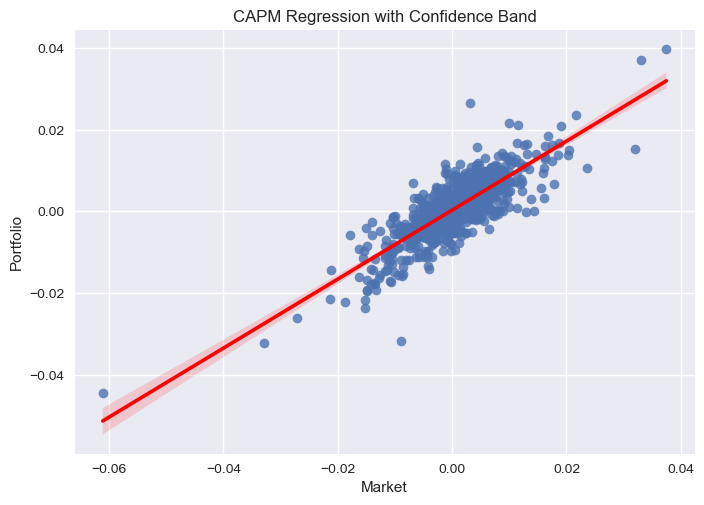

In [52]:
sns.regplot(x='Market', y='Portfolio', data=combined, line_kws={'color':'red'})
plt.title("CAPM Regression with Confidence Band")
plt.show()

In [53]:
var_95 = np.percentile(portfolio_returns, 5)
var_99 = np.percentile(portfolio_returns, 1)

print("Historical VaR (95%):", var_95)
print("Historical VaR (99%):", var_99)

Historical VaR (95%): -0.011778101958861316
Historical VaR (99%): -0.020728507846714466


In [54]:
mean_return = portfolio_returns.mean()
std_dev = portfolio_returns.std()

z_95 = 1.65
z_99 = 2.33

param_var_95 = mean_return - z_95 * std_dev
param_var_99 = mean_return - z_99 * std_dev

print("Parametric VaR (95%):", param_var_95)
print("Parametric VaR (99%):", param_var_99)

Parametric VaR (95%): -0.01206272166299427
Parametric VaR (99%): -0.017340065489451526


In [55]:
es_95 = portfolio_returns[portfolio_returns <= var_95].mean()
es_99 = portfolio_returns[portfolio_returns <= var_99].mean()

print("Expected Shortfall (95%):", es_95)
print("Expected Shortfall (99%):", es_99)

Expected Shortfall (95%): -0.018061997173007584
Expected Shortfall (99%): -0.027905817864944747


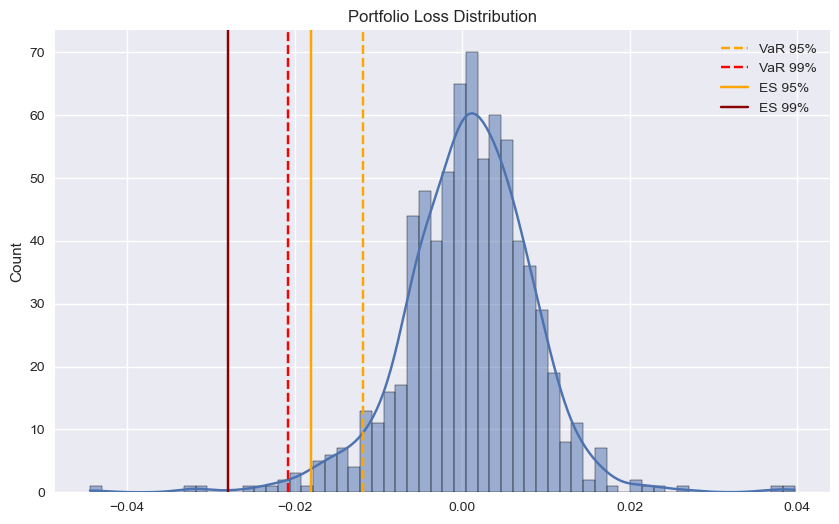

In [56]:
plt.figure(figsize=(10,6))
sns.histplot(portfolio_returns, bins=60, kde=True)

plt.axvline(var_95, color='orange', linestyle='--', label='VaR 95%')
plt.axvline(var_99, color='red', linestyle='--', label='VaR 99%')
plt.axvline(es_95, color='orange', linestyle='-', label='ES 95%')
plt.axvline(es_99, color='darkred', linestyle='-', label='ES 99%')

plt.title("Portfolio Loss Distribution")
plt.legend()
plt.show()

In [57]:
simulated_returns = np.random.normal(mean_return,std_dev, 100000)      

mc_var_95 = np.percentile(simulated_returns, 5)
mc_var_99 = np.percentile(simulated_returns, 1)

mc_es_95 = simulated_returns[simulated_returns <= mc_var_95].mean()
mc_es_99 = simulated_returns[simulated_returns <= mc_var_99].mean()

print("Monte Carlo VaR (95%):", mc_var_95)
print("Monte Carlo VaR (99%):", mc_var_99)
print("Monte Carlo ES (95%):", mc_es_95)
print("Monte Carlo ES (99%):", mc_es_99)

Monte Carlo VaR (95%): -0.01200115081667104
Monte Carlo VaR (99%): -0.01734214743683833
Monte Carlo ES (95%): -0.015266017984296132
Monte Carlo ES (99%): -0.01986524919477405


In [58]:
garch = arch_model(portfolio_returns*100, vol='Garch', p=1, q=1)
garch_fit = garch.fit()

print(garch_fit.summary())

Iteration:      1,   Func. Count:      6,   Neg. LLF: 4439.432601383087
Iteration:      2,   Func. Count:     14,   Neg. LLF: 115435.59246592925
Iteration:      3,   Func. Count:     21,   Neg. LLF: 838.3759267961474
Iteration:      4,   Func. Count:     27,   Neg. LLF: 837.4725320189777
Iteration:      5,   Func. Count:     33,   Neg. LLF: 842.3994147672778
Iteration:      6,   Func. Count:     40,   Neg. LLF: 835.092857831647
Iteration:      7,   Func. Count:     45,   Neg. LLF: 835.0927828936371
Iteration:      8,   Func. Count:     50,   Neg. LLF: 835.0927810534264
Iteration:      9,   Func. Count:     54,   Neg. LLF: 835.0927810534255
Optimization terminated successfully    (Exit mode 0)
            Current function value: 835.0927810534264
            Iterations: 9
            Function evaluations: 54
            Gradient evaluations: 9
                     Constant Mean - GARCH Model Results                      
Dep. Variable:                   None   R-squared:                

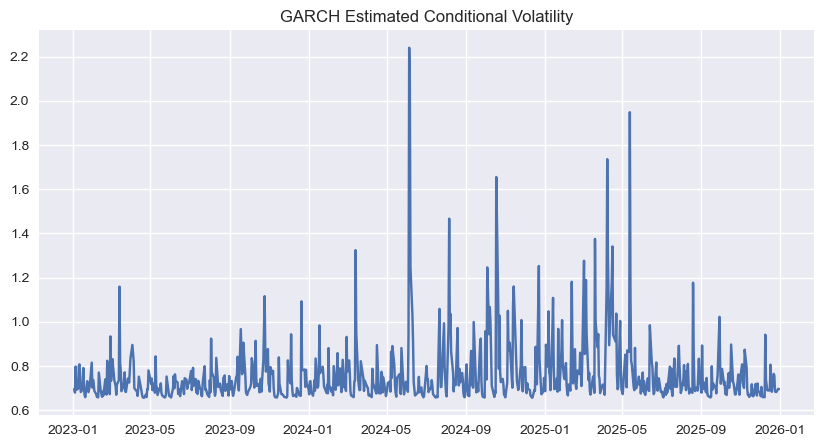

In [59]:
garch_vol = garch_fit.conditional_volatility

plt.figure(figsize=(10,5))
plt.plot(garch_vol)
plt.title("GARCH Estimated Conditional Volatility")
plt.show()

In [60]:
latest_vol = garch_vol.iloc[-1] / 100

garch_var_95 = mean_return - z_95 * latest_vol
garch_var_99 = mean_return - z_99 * latest_vol

print("GARCH VaR 95:", garch_var_95)
print("GARCH VaR 99:", garch_var_99)

GARCH VaR 95: -0.010737653362922695
GARCH VaR 99: -0.015468908435411056


In [61]:
cov_matrix = returns.cov()

df = 4
simulations = 10000

t_random = t.rvs(df, size=(simulations, len(weights)))
chol = np.linalg.cholesky(cov_matrix)

correlated_t = np.dot(t_random, chol)

portfolio_sim = np.dot(correlated_t, weights)

portfolio_sim_std = (portfolio_sim - np.mean(portfolio_sim)) / np.std(portfolio_sim)

portfolio_sim_scaled = mean_return + std_dev * portfolio_sim_std

copula_var_95 = np.percentile(portfolio_sim_scaled, 5)
copula_var_99 = np.percentile(portfolio_sim_scaled, 1)

copula_es_95 = portfolio_sim_scaled[portfolio_sim_scaled <= copula_var_95].mean()
copula_es_99 = portfolio_sim_scaled[portfolio_sim_scaled <= copula_var_99].mean()

print("Copula VaR 95:", copula_var_95)
print("Copula VaR 99:", copula_var_99)
print("Copula ES 95:", copula_es_95)
print("Copula ES 99:", copula_es_99)

Copula VaR 95: -0.011893306262784153
Copula VaR 99: -0.01770270226989561
Copula ES 95: -0.015699409587640874
Copula ES 99: -0.02147941460333634


In [62]:
print("========== PORTFOLIO RISK SUMMARY ==========\n")

# ------------------------------
# Historical VaR
# ------------------------------
print("HISTORICAL VAR")
print("Historical VaR (95%):", var_95)
print("Historical VaR (99%):", var_99)
print()

# ------------------------------
# Parametric VaR
# ------------------------------
print("PARAMETRIC VAR")
print("Parametric VaR (95%):", param_var_95)
print("Parametric VaR (99%):", param_var_99)
print()

# ------------------------------
# Monte Carlo VaR
# ------------------------------
print("MONTE CARLO VAR")
print("Monte Carlo VaR (95%):", mc_var_95)
print("Monte Carlo VaR (99%):", mc_var_99)
print()

# ------------------------------
# Copula VaR
# ------------------------------
print("COPULA VAR")
print("Copula VaR (95%):", copula_var_95)
print("Copula VaR (99%):", copula_var_99)
print()

# ------------------------------
# Expected Shortfall
# ------------------------------
print("EXPECTED SHORTFALL")
print("Historical ES (95%):", es_95)
print("Historical ES (99%):", es_99)
print()

print("Monte Carlo ES (95%):", mc_es_95)
print("Monte Carlo ES (99%):", mc_es_99)
print()

print("Copula ES (95%):", copula_es_95)
print("Copula ES (99%):", copula_es_99)
print()

# ------------------------------
# GARCH Results
# ------------------------------
print("GARCH MODEL RESULTS")
print(garch_fit.summary())

print("\nLatest Estimated Volatility:", garch_vol.iloc[-1])
print("\n========== END OF RESULTS ==========")

========== PORTFOLIO RISK SUMMARY ==========

HISTORICAL VAR
Historical VaR (95%): -0.011778101958861316
Historical VaR (99%): -0.020728507846714466

PARAMETRIC VAR
Parametric VaR (95%): -0.01206272166299427
Parametric VaR (99%): -0.017340065489451526

MONTE CARLO VAR
Monte Carlo VaR (95%): -0.01200115081667104
Monte Carlo VaR (99%): -0.01734214743683833

COPULA VAR
Copula VaR (95%): -0.011893306262784153
Copula VaR (99%): -0.01770270226989561

EXPECTED SHORTFALL
Historical ES (95%): -0.018061997173007584
Historical ES (99%): -0.027905817864944747

Monte Carlo ES (95%): -0.015266017984296132
Monte Carlo ES (99%): -0.01986524919477405

Copula ES (95%): -0.015699409587640874
Copula ES (99%): -0.02147941460333634

GARCH MODEL RESULTS
                     Constant Mean - GARCH Model Results                      
Dep. Variable:                   None   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:            

In [63]:
results = {
    "Metric": [
        "Historical VaR 95%",
        "Historical VaR 99%",
        "Parametric VaR 95%",
        "Parametric VaR 99%",
        "Monte Carlo VaR 95%",
        "Monte Carlo VaR 99%",
        "Copula VaR 95%",
        "Copula VaR 99%",
        "Historical ES 95%",
        "Historical ES 99%",
        "Monte Carlo ES 95%",
        "Monte Carlo ES 99%",
        "Copula ES 95%",
        "Copula ES 99%",
        "Latest GARCH Volatility"
    ],

    "Value": [
        var_95,
        var_99,
        param_var_95,
        param_var_99,
        mc_var_95,
        mc_var_99,
        copula_var_95,
        copula_var_99,
        es_95,
        es_99,
        mc_es_95,
        mc_es_99,
        copula_es_95,
        copula_es_99,
        garch_vol.iloc[-1]
    ]
}

results_df = pd.DataFrame(results)
results_df.to_excel("Final_portfolio_risk_results.xlsx", index=False)

print("Excel file saved successfully")

Excel file saved successfully


In [64]:

market_crash = -0.10

portfolio_impact = beta * market_crash

print("Portfolio Loss in 10% Market Crash:", portfolio_impact*100,"%")

Portfolio Loss in 10% Market Crash: -8.448272414426919 %


In [65]:
beta

np.float64(0.8448272414426918)

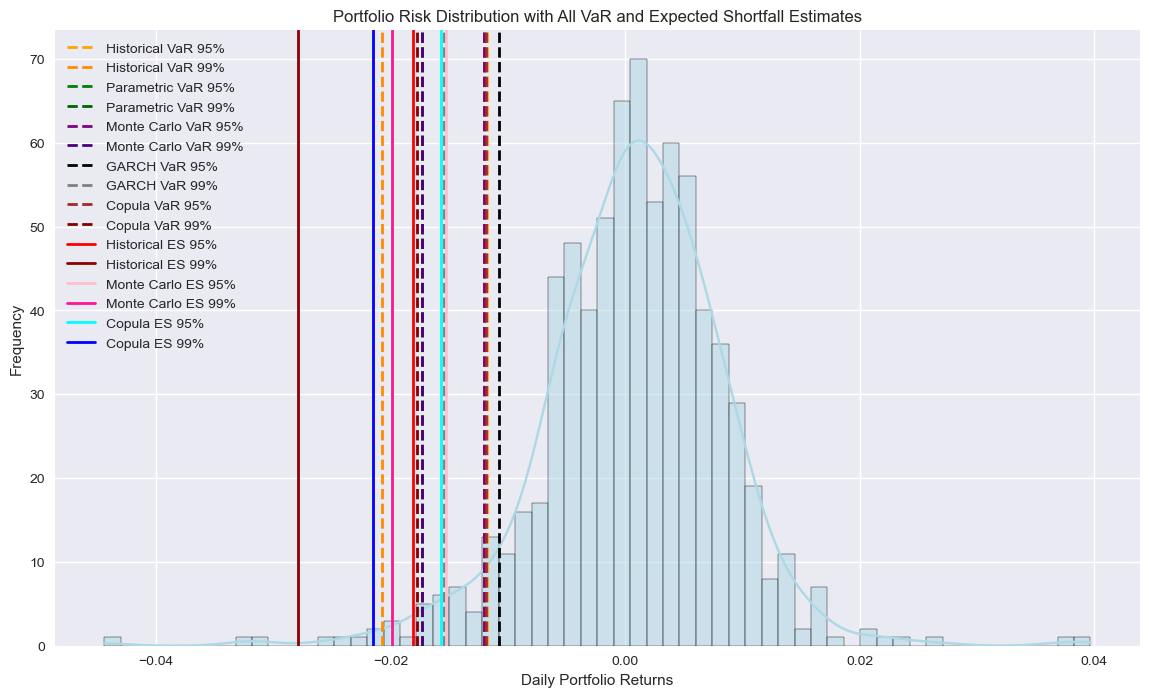

In [66]:
plt.figure(figsize=(14,8))

# Portfolio distribution
sns.histplot(portfolio_returns, bins=60, kde=True, color='lightblue')

# ----------------------------
# HISTORICAL VAR
# ----------------------------

plt.axvline(var_95, color='orange', linestyle='--', linewidth=2, label='Historical VaR 95%')
plt.axvline(var_99, color='darkorange', linestyle='--', linewidth=2, label='Historical VaR 99%')

# ----------------------------
# PARAMETRIC VAR
# ----------------------------

plt.axvline(param_var_95, color='green', linestyle='--', linewidth=2, label='Parametric VaR 95%')
plt.axvline(param_var_99, color='darkgreen', linestyle='--', linewidth=2, label='Parametric VaR 99%')

# ----------------------------
# MONTE CARLO VAR
# ----------------------------

plt.axvline(mc_var_95, color='purple', linestyle='--', linewidth=2, label='Monte Carlo VaR 95%')
plt.axvline(mc_var_99, color='indigo', linestyle='--', linewidth=2, label='Monte Carlo VaR 99%')

# ----------------------------
# GARCH VAR
# ----------------------------

plt.axvline(garch_var_95, color='black', linestyle='--', linewidth=2, label='GARCH VaR 95%')
plt.axvline(garch_var_99, color='gray', linestyle='--', linewidth=2, label='GARCH VaR 99%')

# ----------------------------
# COPULA VAR
# ----------------------------

plt.axvline(copula_var_95, color='brown', linestyle='--', linewidth=2, label='Copula VaR 95%')
plt.axvline(copula_var_99, color='maroon', linestyle='--', linewidth=2, label='Copula VaR 99%')

# ----------------------------
# HISTORICAL ES
# ----------------------------

plt.axvline(es_95, color='red', linestyle='-', linewidth=2, label='Historical ES 95%')
plt.axvline(es_99, color='darkred', linestyle='-', linewidth=2, label='Historical ES 99%')

# ----------------------------
# MONTE CARLO ES
# ----------------------------

plt.axvline(mc_es_95, color='pink', linestyle='-', linewidth=2, label='Monte Carlo ES 95%')
plt.axvline(mc_es_99, color='deeppink', linestyle='-', linewidth=2, label='Monte Carlo ES 99%')

# ----------------------------
# COPULA ES
# ----------------------------

plt.axvline(copula_es_95, color='cyan', linestyle='-', linewidth=2, label='Copula ES 95%')
plt.axvline(copula_es_99, color='blue', linestyle='-', linewidth=2, label='Copula ES 99%')

plt.title("Portfolio Risk Distribution with All VaR and Expected Shortfall Estimates")
plt.xlabel("Daily Portfolio Returns")
plt.ylabel("Frequency")

plt.legend(loc='upper left')
plt.grid(True)

plt.show()